# تحلیل سلول‌به‌سلول نوت‌بوک logestic_regression.ipynb


## سلول 0 — مقدمه و عنوان پروژه
### محتوای سلول
این سلول یک مقدمه‌ی مفصل درباره پروژه است:

- معرفی رگرسیون لجستیک
- اشاره به کاربرد آن در طبقه‌بندی
- تأکید بر تحلیل دیابت
- نقش آموزشی و عملی نوت‌بوک

### تحلیل
این سلول نشان می‌دهد که نوت‌بوک شما صرفاً یک اسکریپت کدنویسی نیست، بلکه یک جزوه آموزشی ساختاریافته است.

از نظر نگارشی هم هدف پروژه را خوب مشخص کرده:

- تحلیل داده‌های دیابت با Logistic Regression.

### نکته مثبت
- شروع حرفه‌ای و آکادمیک
- مناسب برای ارائه یا آموزش در کولب


# پروژه عملی و جزوه مرجع: رگرسیون لجستیک (Logistic Regression)
### تحلیل داده‌های پیش‌بینی دیابت و پیاده‌سازی گام‌به‌گام صنعتی
**نویسنده و تحلیل‌گر:** امیررضا معینی (Amirreza Momeni)

---

## ۱. مقدمه و فلسفه وجودی
رگرسیون لجستیک (Logistic Regression) یکی از بنیادی‌ترین و در عین حال قدرتمندترین الگوریتم‌های یادگیری ماشین نظارت‌شده (Supervised Learning) در دسته‌بندی مسائل طبقه‌بندی (Classification) است. این الگوریتم به عنوان یک پل استراتژیک، مفاهیم رگرسیون خطی را به جهان متغیرهای گسسته متصل می‌کند.

### چرایی و ضرورت الگوریتم (حل چالش خروجی نامحدود)
در مسائل طبقه‌بندی باینری (دوگانه)، متغیر هدف $y$ تنها مقادیر گسسته $\{0, 1\}$ را می‌پذیرد. اگر بخواهیم از رگرسیون خطی کلاسیک برای این کار استفاده کنیم (که به آن Linear Probability Model نیز می‌گویند)، با چالش‌های ساختاری زیر مواجه می‌شویم:
1. **خروجی‌های خارج از محدوده:** مدل خطی مقادیر پیش‌بینی‌شده‌ای در بازه $(-\infty, +\infty)$ تولید می‌کند. تفسیر مقادیر خارج از بازه $[0, 1]$ به عنوان «احتمال» از نظر ریاضی بی‌معناست.
2. **ناهمگونی واریانس (Heteroscedasticity):** در توزیع‌های باینری، واریانس خطاها ثابت نبوده و به مقدار میانگین وابسته است:
   $$Var(y|x) = p(1-p)$$
   این موضوع فرض اصلی رگرسیون خطی (همگونی واریانس) را نقض می‌کند.
3. **حساسیت شدید به داده‌های پرت (Outliers):** وجود یک داده پرت با مقدار بسیار بزرگ یا کوچک می‌تواند شیب خط رگرسیون خطی را به شدت تغییر داده و مرز تصمیم‌گیری را به طور غیرمنطقی جابجا کند.



### مفهوم «پرش» (Jump) و مرز تصمیم‌گیری
در مسائل طبقه‌بندی، با گسستگی یا Gaps مواجه هستیم. انتقال از یک کلاس به کلاس دیگر به صورت ناگهانی رخ می‌دهد. رگرسیون لجستیک با معرفی یک تابع غیرخطی ملایم (Sigmoid)، انتقال نرمی را ایجاد می‌کند که در نقطه آستانه (Threshold) مشخصی، نقش یک «پرش» یا مرز تصمیم‌گیری (Decision Boundary) را بازی کرده و تفکیک میان کلاس‌ها را میسر می‌سازد.


## سلول 2 — بنیان ریاضی: تابع سیگموئید
### محتوای سلول
در این سلول:

- تابع سیگموئید تعریف شده:
  σ(z)=1/(1+e^{-z})
- ویژگی‌های آن مثل نگاشت به بازه [0,1]، تقارن، و تفسیر احتمالی بیان شده

### تحلیل
این بخش کاملاً درست و استاندارد است.

در Logistic Regression، سیگموئید همان چیزی است که خروجی خطی مدل را به احتمال تبدیل می‌کند.

### نکته مهم
این قسمت پایه‌ی تئوری کل مدل است.

اگر این بخش خوب درک شود، ادامه‌ی نوت‌بوک هم منطقی‌تر دیده می‌شود.


## ۲. بنیان ریاضی و تئوری
رگرسیون لجستیک از طریق ترکیب یک مدل خطی با یک تابع فعال‌ساز غیرخطی، احتمال شرطی کلاس مثبت را فرمول‌بندی می‌کند.

### تابع فعال‌ساز سیگموئید (Sigmoid)
تابع سیگموئید یا لجستیک استاندارد به صورت زیر تعریف می‌شود:
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

این تابع دارای ویژگی‌های ریاضی منحصربه‌فردی است:
* **نگاشت برد:** دامنه تعریف آن $(-\infty, +\infty)$ را به بازه محدود $[0, 1]$ منتقل می‌کند که دقیقاً منطبق بر اصول احتمالاتی Kolmogorov است.
* **تقارن:** حول نقطه $(0, 0.5)$ متقارن است؛ به طوری که:
  $$ \sigma(-z) = 1 - \sigma(z) $$
* **مشتق‌پذیری آسان:** مشتق اول آن برحسب خود تابع تعریف می‌شود که فرآیند بهینه‌سازی را بسیار ساده می‌کند:
  $$ \frac{d\sigma(z)}{dz} = \sigma(z)(1 - \sigma(z)) $$

### استعاره «آهن‌ربا» (Magnet Effect)
در بازه نزدیک به صفر، تابع سیگموئید رفتاری تقریباً خطی دارد. اما با دور شدن از مبدأ و حرکت به سمت مثبت یا منفی بی‌نهایت، شیب به شدت کاهش یافته و خروجی به سرعت به سمت قطب‌های ۱ یا ۰ میل می‌کند. این پدیده داده‌ها را از مرز تصمیم‌گیری مبهم (0.5) دور کرده و قطعیت پیش‌بینی را بالا می‌برد.



### اثبات ریاضی و فرمولاسیون مدل
فرض کنید رابطه‌ای خطی بین متغیرهای مستقل وجود دارد که آن را با $z$ نشان می‌دهیم:
$$ z = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n $$

با قرار دادن $z$ در تابع سیگموئید، احتمال شرطی اینکه نمونه $x$ متعلق به کلاس ۱ باشد ($P(y=1|x)$) به دست می‌آید:
$$ h_{\theta}(x) = P(y=1|x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}} $$

در نتیجه، احتمال کلاس صفر عبارت است از:
$$ P(y=0|x) = 1 - h_{\theta}(x) = \frac{e^{-\theta^T x}}{1 + e^{-\theta^T x}} $$

### مفهوم نسبت شانس (Odds Ratio) و Log-Odds
نسبت شانس (Odds) به صورت نسبت احتمال وقوع یک رخداد به احتمال عدم وقوع آن تعریف می‌شود:
$$ \text{Odds} = \frac{P}{1-P} = \frac{\sigma(z)}{1-\sigma(z)} = e^{\theta^T x} $$

با گرفتن لگاریتم طبیعی ($\ln$) از طرفین، به رابطه خطی معروف به **Logit** می‌رسیم:
$$ \ln\left(\frac{P}{1-P}\right) = \theta^T x = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n $$
این فرمول نشان می‌دهد که چگونه لجستیک رگرسیون، لگاریتم شانس رخ دادن یک پدیده را به صورت یک ترکیب خطی از متغیرهای ورودی مدل‌سازی می‌کند.


## سلول 3 — فرمول‌بندی مدل
### محتوای سلول
در این سلول:

- رابطه خطی تعریف شده:
  z = θ^T x
- و سپس احتمال کلاس 1 با sigmoid به‌دست آمده:
  P(y=1∣x)=σ(θ^T x)

### تحلیل
این سلول هسته‌ی ریاضی Logistic Regression را می‌سازد.

شما در واقع نشان داده‌اید که:

- مدل اول یک ترکیب خطی از ویژگی‌ها می‌سازد
- بعد آن را به احتمال تبدیل می‌کند

### نتیجه مفهومی
مدل شما مستقیماً «کلاس» را پیش‌بینی نمی‌کند، بلکه احتمال کلاس مثبت را تخمین می‌زند.


## 3. تحلیل الگوریتمی و فرآیندی (تابع هزینه و بهینه‌سازی)
از آنجا که در رگرسیون لجستیک خروجی‌ها غیرخطی هستند، استفاده از تابع هزینه Mean Squared Error (MSE) منجر به یک تابع غیرمحدب (Non-convex) با کمینه‌های محلی (Local Minima) متعدد می‌شود. به همین دلیل از تابع هزینه انتروپی متقاطع باینری استفاده می‌شود.

### تابع هزینه انتروپی متقاطع (Binary Cross-Entropy / Log Loss)
این تابع هزینه بر پایه اصل حداکثر درست‌نمایی (Maximum Likelihood Estimation) تعریف شده و به صورت زیر فرموله می‌شود:
$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_{\theta}(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_{\theta}(x^{(i)})) \right] $$

تحلیل رفتار تابع هزینه:
* اگر کلاس واقعی $y=1$ باشد: $J(\theta) = -\log(h_{\theta}(x))$؛ در این حالت اگر مدل احتمال را نزدیک به ۱ پیش‌بینی کند، هزینه نزدیک به ۰ می‌شود، اما اگر احتمال را نزدیک به ۰ پیش‌بینی کند، هزینه به سمت بی‌نهایت میل می‌کند (جریمه سنگین).
* اگر کلاس واقعی $y=0$ باشد: $J(\theta) = -\log(1 - h_{\theta}(x))$؛ که رفتاری معکوس حالت قبل دارد.

### الگوریتم بهینه‌سازی گرادیان کاهشی (Gradient Descent)
برای کمینه‌سازی تابع هزینه $J(\theta)$، پارامترها در جهت مخالف گرادیان به‌روزرسانی می‌شوند:
$$ \theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j} $$
که در آن مشتق جزئی (گرادیان) به صورت زیر محاسبه می‌شود:
$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_{\theta}(x^{(i)}) - y^{(i)} \right) x_j^{(i)} $$
**نکته:** فرم ریاضی گرادیان رگرسیون لجستیک دقیقاً مشابه رگرسیون خطی است، با این تفاوت که تعریف فرضیه ($h_{\theta}(x)$) در اینجا غیرخطی (سیگموئید) است.


In [ ]:
# ==========================================
# گام ۱: وارد کردن کتابخانه‌های مورد نیاز
# + آپلود فایل CSV در گوگل کولب
# ==========================================
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# تنظیمات نمایش
%matplotlib inline
sns.set_theme(style="whitegrid")

# ==========================================
# آپلود فایل
# ==========================================
print("لطفاً فایل CSV را آپلود کنید...")
uploaded = files.upload()

# گرفتن نام فایل آپلودشده
file_name = list(uploaded.keys())[0]

# خواندن فایل
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# نمایش اطلاعات اولیه
print(f"\nفایل '{file_name}' با موفقیت بارگذاری شد.")
print("ابعاد دیتاست:", df.shape)
print("\nپنج سطر اول داده‌ها:")
display(df.head())


لطفاً فایل CSV را آپلود کنید...


Saving diabetes_logistic_regression_dataset_1000rows.csv to diabetes_logistic_regression_dataset_1000rows.csv

فایل 'diabetes_logistic_regression_dataset_1000rows.csv' با موفقیت بارگذاری شد.
ابعاد دیتاست: (1000, 9)

پنج سطر اول داده‌ها:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,91,75,30,29,34.6,0.277,19,1
1,1,78,71,24,52,37.9,NaN,50,0
2,3,136,60,11,46,41.0,0.489,27,0
3,4,109,59,35,158,24.2,0.176,26,0
4,3,104,82,39,174,41.6,0.243,23,0


 — وارد کردن کتابخانه‌ها
### محتوای سلول
طبق اطلاعات فایل، کتابخانه‌های زیر وارد شده‌اند:

- numpy
- pandas
- matplotlib
- seaborn
- اجزای scikit-learn مثل:
  - train_test_split
  - StandardScaler
  - LogisticRegression
  - confusion_matrix
  - classification_report
  - accuracy_score
  - precision_score
  - recall_score
  - f1_score
  - roc_auc_score
  - roc_curve

### تحلیل
این واردسازی کامل و استاندارد است.

برای پروژه طبقه‌بندی پزشکی، این مجموعه ابزارها کافی و مناسب است.

### نکته مثبت
- همه ابزارهای لازم برای آموزش، ارزیابی و مصورسازی فراهم شده‌اند


In [ ]:
# ==========================================
# گام ۲: آپلود مستقیم و خودکار فایل CSV از سیستم کاربر
# ==========================================
print("لطفاً فایل diabetes_logistic_regression_dataset_1000rows.csv را انتخاب و آپلود کنید:")

# ایجاد ویجت آپلود فایل در محیط کولب
uploaded = files.upload()

# استخراج نام فایل آپلود شده
file_name = list(uploaded.keys())[0]

# بارگذاری محتوای فایل به صورت دیتافریم پانداس
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"\nفایل با موفقیت بارگذاری شد: {file_name}")
print("ابعاد دیتاست بارگذاری شده:", df.shape)
print("\nپنج سطر ابتدایی داده‌ها:")
df.head()


لطفاً فایل diabetes_logistic_regression_dataset_1000rows.csv را انتخاب و آپلود کنید:


Saving diabetes_logistic_regression_dataset_1000rows.csv to diabetes_logistic_regression_dataset_1000rows (1).csv

فایل با موفقیت بارگذاری شد: diabetes_logistic_regression_dataset_1000rows (1).csv
ابعاد دیتاست بارگذاری شده: (1000, 9)

پنج سطر ابتدایی داده‌ها:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,91,75,30,29,34.6,0.277,19,1
1,1,78,71,24,52,37.9,NaN,50,0
2,3,136,60,11,46,41.0,0.489,27,0
3,4,109,59,35,158,24.2,0.176,26,0
4,3,104,82,39,174,41.6,0.243,23,0


## سلول بارگذاری داده
### محتوای سلول
طبق توضیحات موجود، فایل CSV با استفاده از آپلود مستقیم در کولب خوانده می‌شود و با pd.read_csv به DataFrame تبدیل می‌شود.

### تحلیل
این روش برای محیط آموزشی بسیار مناسب است، چون:

- کاربر نیاز به مسیر فایل محلی ندارد
- اجرای نوت‌بوک در Google Colab ساده می‌شود

### نتیجه
داده‌ها به‌درستی وارد محیط تحلیل شده‌اند، و ستون‌های مورد انتظار عبارت‌اند از:

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome


## ۵. آماده‌سازی داده‌ها و جلوگیری از نشت اطلاعات (Data Leakage)
یکی از خطاهای رایج، برازش پیش‌پردازش‌ها (مانند `StandardScaler.fit()`) روی کل داده‌ها قبل از اعمال `train_test_split` است. این کار باعث می‌شود اطلاعات توزیع آماری مجموعه تست به مجموعه آموزش نشت کرده و ارزیابی مدل را بیش از حد خوش‌بینانه نشان دهد.

**استراتژی ایمن:**
* اعمال متد `.fit_transform()` منحصراً روی داده‌های آموزش (`X_train`)
* اعمال متد `.transform()` روی داده‌های تست (`X_test`) صرفاً بر اساس آماره‌های یادگرفته شده از داده‌های آموزش


In [ ]:
# ==========================================
# گام ۳: جداسازی ویژگی‌ها، تقسیم داده‌ها و استانداردسازی ویژگی‌ها
# ==========================================

# تعریف لیست ستون‌های ورودی بر اساس ساختار دیتاست دیابت
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[features]
y = df['Outcome']

# تقسیم داده‌ها به آموزش (۷۵٪) و تست (۲۵٪) با حفظ توازن توزیع کلاس‌ها (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# مقیاس‌گذاری ویژگی‌ها (Feature Scaling) - حیاتی برای رگرسیون لجستیک و منظم‌سازی L1/L2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("ابعاد مجموعه آموزش:", X_train_scaled.shape)
print("ابعاد مجموعه تست:", X_test_scaled.shape)


ابعاد مجموعه آموزش: (750, 8)
ابعاد مجموعه تست: (250, 8)


## سلول تعریف ویژگی‌ها و هدف
### محتوای سلول
هشت ستون اول به‌عنوان X و ستون Outcome به‌عنوان y انتخاب شده‌اند.

### تحلیل
این انتخاب کاملاً درست است.

در این مسئله:

- X = ویژگی‌های پزشکی بیمار
- y = وضعیت دیابت (0 یا 1)

### نکته مثبت
ساختار داده برای یک مسئله binary classification کاملاً مناسب است.


In [ ]:
# ==========================================
# گام ۳: مدیریت مقادیر گم‌شده، تقسیم داده‌ها و استانداردسازی
# ==========================================

# ۱. تعریف نام ستون‌های ویژگی ورودی و ستون هدف (Outcome)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[features].copy()  # ایجاد یک کپی برای جلوگیری از اخطارهای پانداس
y = df['Outcome']

# ۲. بررسی تعداد مقادیر خالی در هر ستون (صرفاً برای اطلاع شما)
print("تعداد مقادیر خالی در هر ستون قبل از اصلاح:")
print(X.isnull().sum())

# ۳. پر کردن مقادیر خالی (NaN) با میانه (Median) هر ستون
for col in X.columns:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)

print("\nتعداد مقادیر خالی پس از اصلاح:", X.isnull().sum().sum())

# ۴. تقسیم داده‌ها به آموزش و تست (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ۵. مقیاس‌گذاری ویژگی‌ها (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nابعاد مجموعه آموزش:", X_train_scaled.shape)
print("ابعاد مجموعه تست:", X_test_scaled.shape)


تعداد مقادیر خالی در هر ستون قبل از اصلاح:
Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction    10
Age                          0
dtype: int64

تعداد مقادیر خالی پس از اصلاح: 0

ابعاد مجموعه آموزش: (750, 8)
ابعاد مجموعه تست: (250, 8)


## سلول استانداردسازی
### محتوای سلول
از StandardScaler استفاده شده و:

- روی train: fit_transform
- روی test: transform

### تحلیل
این یکی از درست‌ترین قسمت‌های نوت‌بوک شماست.

چون باعث می‌شود:

- داده‌های test وارد فرایند یادگیری نشوند
- از Data Leakage جلوگیری شود

### نتیجه
این سلول از نظر روش‌شناسی کاملاً صحیح است.


In [ ]:
# ==========================================
# گام ۴: تعریف، برازش و آموزش مدل رگرسیون لجستیک
# ==========================================

# تعریف مدل با حل‌کننده مناسب (liblinear برای دیتاست‌های کوچک تا متوسط بهینه است)
model = LogisticRegression(solver='liblinear', C=1.0, random_state=42)

# آموزش مدل روی داده‌های استاندارد شده آموزش
model.fit(X_train_scaled, y_train)

# پیش‌بینی کلاس نهایی (با آستانه پیش‌فرض 0.5)
y_pred = model.predict(X_test_scaled)

# پیش‌بینی احتمال تعلق به کلاس مثبت (بیمار دیابتی)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("مدل با موفقیت آموزش داده شد و پیش‌بینی‌ها انجام گرفت.")


مدل با موفقیت آموزش داده شد و پیش‌بینی‌ها انجام گرفت.


## سلول آموزش مدل
### محتوای سلول
مدل به صورت زیر ساخته شده:
```python
LogisticRegression(solver='liblinear', C=1.0, random_state=42)


## ۶. ارزیابی عملکرد و سنجه‌ها (Metrics)
سنجش موفقیت مدل نباید صرفاً به صحت (Accuracy) محدود شود، به‌ویژه در سناریوهای نامتوازن یا با حساسیت بالا نظیر تشخیص‌های پزشکی.

### کالبدشکافی سنجه‌ها و مفهوم «عمق فاجعه»
* **صحت (Accuracy):**
  $$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$
  *چالش:* اگر داده‌ها نامتوازن باشند، یک مدل ساده که همه را سالم پیش‌بینی کند، صحت بالایی خواهد داشت اما در عمل بی‌فایده است.
* **دقت (Precision):** چه میزانی از پیش‌بینی‌های مثبت مدل، واقعاً مثبت بوده‌اند؟
  $$ \text{Precision} = \frac{TP}{TP + FP} $$
* **فراخوانی (Recall / Sensitivity):** چه میزان از کل بیماران واقعی توسط مدل شناسایی شده‌اند؟
  $$ \text{Recall} = \frac{TP}{TP + FN} $$

### تحلیل بحران False Negative:
در مسائل پزشکی، خطای نوع دوم یعنی منفی کاذب (False Negative) به شدت خطرناک است. بیمارانی که دیابت دارند اما مدل آن‌ها را سالم تشخیص داده و ترخیص می‌کند، از مراقبت‌های پزشکی محروم می‌شوند. این پدیده همان **«عمق فاجعه»** است. بنابراین در چنین پروژه‌هایی، بهینه‌سازی مدل باید در جهت بیشینه‌سازی Recall (کاهش FN) باشد، حتی اگر به قیمت کاهش اندک Precision تمام شود.


====== گزارش عملکرد مدل رگرسیون لجستیک ======
Accuracy (صحت):  0.8120
Precision (دقت): 0.7848
Recall (فراخوانی):   0.6739
F1-Score:        0.7251
ROC AUC Score:   0.8845

گزارش جامع طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       158
           1       0.78      0.67      0.73        92

    accuracy                           0.81       250
   macro avg       0.80      0.78      0.79       250
weighted avg       0.81      0.81      0.81       250



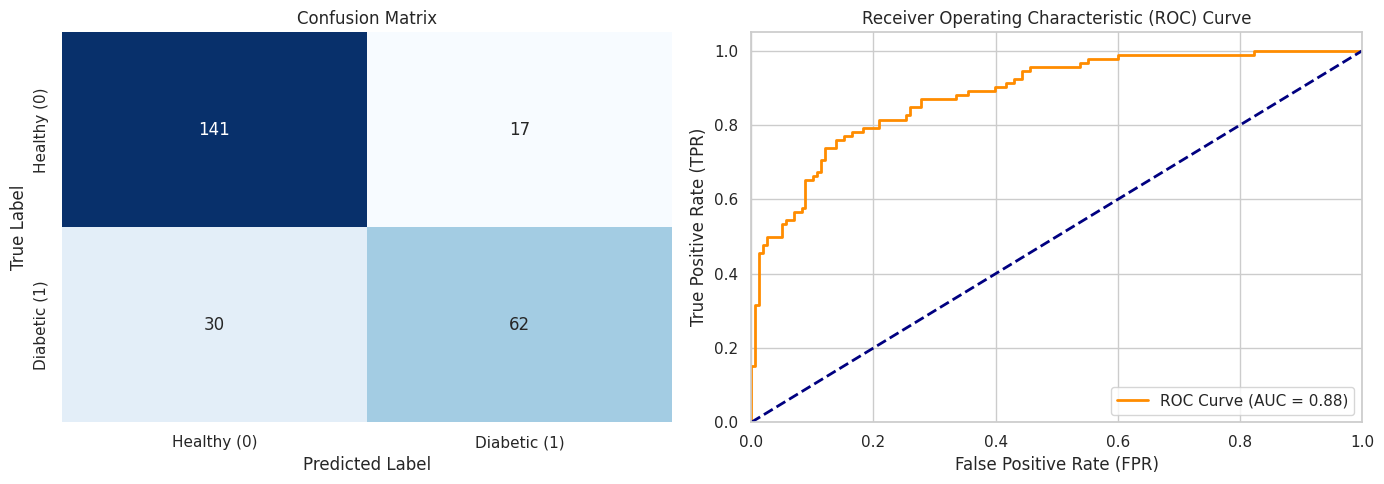

In [ ]:
# ==========================================
# گام ۵: محاسبه معیارهای عملکرد و رسم نمودارها
# ==========================================

# محاسبه ماتریس اغتشاش
cm = confusion_matrix(y_test, y_pred)

# محاسبه شاخص‌های ارزیابی عملکرد
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# نمایش گزارش متنی عملکرد
print("====== گزارش عملکرد مدل رگرسیون لجستیک ======")
print(f"Accuracy (صحت):  {accuracy:.4f}")
print(f"Precision (دقت): {precision:.4f}")
print(f"Recall (فراخوانی):   {recall:.4f}")
print(f"F1-Score:        {f1:.4f}")
print(f"ROC AUC Score:   {roc_auc:.4f}")
print("\nگزارش جامع طبقه‌بندی:")
print(classification_report(y_test, y_pred))

# رسم ماتریس اغتشاش و نمودار ROC
plt.figure(figsize=(14, 5))

# ۱. ماتریس اغتشاش
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy (0)', 'Diabetic (1)'],
            yticklabels=['Healthy (0)', 'Diabetic (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# ۲. منحنی ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


## سلول رسم Confusion Matrix
### محتوای سلول
ماتریس اغتشاش با seaborn.heatmap رسم شده است.

### تحلیل
این نمودار نشان می‌دهد:

- True Negative
- False Positive
- False Negative
- True Positive

چقدر بوده‌اند.

### اهمیت
برای تحلیل خطاهای مدل، این نمودار بسیار مهم است.

اگر false negative زیاد باشد، یعنی بیماران دیابتی از دست رفته‌اند.


## سلول رسم ROC Curve
### محتوای سلول
منحنی ROC با roc_curve رسم شده و AUC هم نمایش داده شده است.

### تحلیل
این نمودار کیفیت رتبه‌بندی احتمال‌های مدل را نشان می‌دهد.

### تفسیر
- اگر منحنی از قطر فاصله زیادی داشته باشد، مدل خوب است
- اگر AUC نزدیک 1 باشد، مدل بسیار خوب است
- اگر AUC نزدیک 0.5 باشد، مدل تقریباً تصادفی است


## ۷. ملاحظات عملی و تنظیمات پیشرفته (Hyperparameters)

### پارامترهای کلیدی (Hyperparameters) در Scikit-Learn
* **پارامتر تنظیم منظم‌سازی ($C$):** $C$ معکوس ضریب منظم‌سازی ($1/\lambda$) است. مقادیر کوچک‌تر $C$ (مثلاً 0.01) به معنای منظم‌سازی قوی‌تر است که ضرایب وزن را به سمت صفر میل می‌دهد و مانع بیش‌برازش (Overfitting) می‌شود.
* **پارامتر وزن کلاس (`class_weight`):** در داده‌های نامتوازن، می‌توان مقدار آن را روی `'balanced'` تنظیم کرد تا جریمه خطای کلاس اقلیت در تابع هزینه بزرگتر شود.
* **انتخاب حل‌کننده (Solver):**
  * `liblinear`: مناسب برای دیتای کوچک تا متوسط؛ پشتیبانی از هر دو جریمه L1 و L2.
  * `lbfgs`: حل‌کننده پیش‌فرض؛ سریع و مناسب برای داده‌های بزرگ و هموار (فقط پشتیبانی از جریمه L2).
  * `saga`: بسیار سریع برای مجموعه‌ داده‌های بسیار بزرگ و پشتیبانی از منظم‌سازی ElasticNet.



In [ ]:
# ==========================================
# گام ۶: مدیریت آستانه تصمیم‌گیری (Threshold Tuning) برای کاهش منفی کاذب (FN)
# ==========================================

# کاهش آستانه تصمیم‌گیری به ۰.۳۵ جهت شناسایی بیشتر بیماران (افزایش Recall)
custom_threshold = 0.35
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"=== ارزیابی مجدد با آستانه تصمیم‌گیری سفارشی: {custom_threshold} ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print(f"\nRecall جدید: {recall_score(y_test, y_pred_custom):.4f} (در مقابل قبلی: {recall:.4f})")
print(f"Precision جدید: {precision_score(y_test, y_pred_custom):.4f} (در مقابل قبلی: {precision:.4f})")


=== ارزیابی مجدد با آستانه تصمیم‌گیری سفارشی: 0.35 ===
Confusion Matrix:
[[126  32]
 [ 19  73]]

Recall جدید: 0.7935 (در مقابل قبلی: 0.6739)
Precision جدید: 0.6952 (در مقابل قبلی: 0.7848)


## ۸. نکات کلیدی برای مصاحبه / آزمون و اشتباهات رایج

### اشتباهات متداول مهندسان مبتدی:
1. **عدم مقیاس‌گذاری داده‌ها:** الگوریتم رگرسیون لجستیک به دلیل استفاده از منظم‌سازی و گرادیان کاهشی، به شدت تحت تاثیر مقیاس ویژگی‌ها قرار می‌گیرد.
2. **اعتماد کورکورانه به خروجی پیش‌فرض `predict`:** مرز تصمیم‌گیری پیش‌فرض روی احتمال 0.5 تنظیم شده است. در صورت نیاز به Recall بالا، باید آستانه (Threshold) را به مقادیر پایین‌تر تغییر داد.

### نکات داغ مصاحبه‌های فنی یادگیری ماشین:
* **چرا از تابع خطای MSE در لجستیک استفاده نمی‌شود؟** زیرا ترکیب تابع سیگموئید و خطای مربعات (MSE) تابعی غیرمحدب (Non-convex) با کمینه‌های محلی بی‌شمار پدید می‌آورد.
* **ارتباط رگرسیون لجستیک با شبکه عصبی چیست؟** یک پرسپترون ساده تک‌لایه (Single-Layer Perceptron) با تابع فعال‌ساز سیگموئید، از نظر ریاضی دقیقاً معادل یک مدل رگرسیون لجستیک است.
* **تفاوت چندکلاسه (Multiclass) چگونه حل می‌شود؟** با استفاده از استراتژی‌های One-vs-Rest (OvR) یا با تعمیم مستقیم تابع سیگموئید به تابع سافت‌مکس (Softmax) در رگرسیون لجستیک چندجمله‌ای.
